qiskit_runtime_service.__init__:WARNING:2026-09-29 12:04:15,300: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-29 12:04:15,302: Using instance: open-instance, plan: open


Qubit 0
Reported T1 = 212.70 us
Reported T2 = 303.18 us
Delays (us):
[  0.          53.17463414 106.34926828 159.52390242 212.69853655
 265.87317069 319.04780483 372.22243897 425.39707311 478.57170725
 531.74634139 584.92097553 638.09560966]


/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 13294 [dt] = 5.317600e-05 [s] from 5.317463e-05 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 26587 [dt] = 1.063480e-04 [s] from 1.063493e-04 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 39881 [dt] = 1.595240e-04 [s] from 1.595239e-04 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 53175 [dt] = 2.127000e-04 [s] from 2.126985e-04 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to

Job ID: d3fe15e5-3a77-431d-abef-9347e22ff345


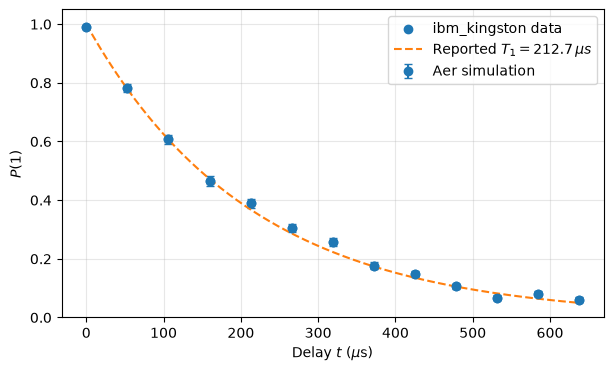

In [ ]:
'''currently, this simulates a T1 calibration on qubit q0 with the noise 
model of ibm_kingston. to run on real hardware change the backend 
to real_backend and ensure api key added. this curve fits to an exponential, 
with error bars based off a binomial distribution of shot noise and used to 
weight the curvefit. displayed uncertainties are purely from curvefit cov'''

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit_aer import AerSimulator

service = QiskitRuntimeService()

real_backend = service.backend("ibm_kingston")

#print("Backend:", backend.name)

backend = AerSimulator.from_backend(real_backend)

'''to run on real hardware, set backend=real_backend, not aer'''

#choose physical qubit (first one)
q = 0

#get current reported calibration properties
props = real_backend.properties(refresh=True)

T1_reported = props.t1(q)
T2_reported = props.t2(q)

print(f"Qubit {q}")
print(f"Reported T1 = {T1_reported * 1e6:.2f} us")
print(f"Reported T2 = {T2_reported * 1e6:.2f} us")


#range time over 3x their reported T1 to get enough data for exponential
times = np.linspace(0, 3 * T1_reported, 13)

print("Delays (us):")
print(times * 1e6)


#build 13 T1 circuits - 13 bc cheap for testing but enough to see the curve
circuits = []

for t in times:

    qc = QuantumCircuit(1)

    #prepare 1
    qc.x(0)

    #relax for time t
    qc.delay(t, 0, unit="s")

    #measure
    qc.measure_all()

    circuits.append(qc)


#transpile onto physical qubit q
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1,
    initial_layout=[q],
    scheduling_method="alap"
)

isa_circuits = pm.run(circuits)


#run all delay points in onejob
sampler = SamplerV2(mode=backend)

shots = 1000

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Job ID:", job.job_id())

result = job.result()

#extract P(1) for each delay
p1 = []
e1 = []

for r in result:

    counts = r.data.meas.get_counts()

    N = sum(counts.values()) #total no. shots
    p = counts.get("1", 0)/N
    p1.append(p) #p1 = N1/N = P(1)
    e1.append(np.sqrt(p*(1-p)/N))

p1 = np.array(p1)
e1=np.array(e1)


plt.figure(figsize=(7, 4))
#plot result
plt.scatter(
    times * 1e6,
    p1,
    label="ibm_kingston data"
)
plt.errorbar(
    times * 1e6,
    p1,
    yerr=e1,
    fmt="o",
    capsize=3,
    label="Aer simulation"
)

#plot reference curve
t_fine = np.linspace(0, 3 * T1_reported, 500)

plt.plot(
    t_fine * 1e6,
    np.exp(-t_fine / T1_reported),
    linestyle="--",
    label=fr"Reported $T_1={T1_reported*1e6:.1f}\,\mu s$"
)

plt.xlabel(r"Delay $t$ ($\mu$s)")
plt.ylabel(r"$P(1)$")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

IBM Kingston — run 1
Curve-fit T1 = 213.30 +/- 8.96 us
Reported T1  = 212.70 us
Curve fit:      A = 0.9825, c = 0.0100
Reported-T1 fit: A = 0.9818, c = 0.0107


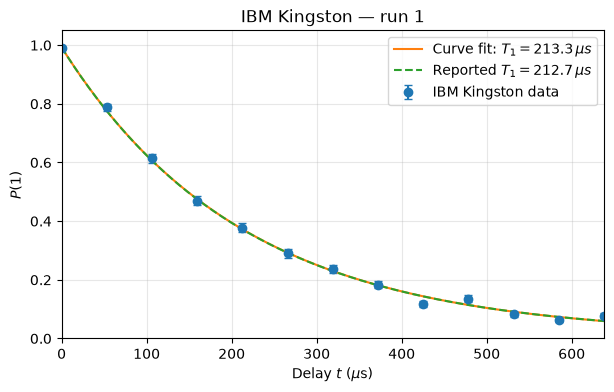

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def exponentialFunc(t, A, T1, c):
    return A * np.exp(-t / T1) + c


def plot_T1_run(times, p1, T1_reported, run_name):
    #in case there are any 0 errors doing this to avoid divide by zero
    errors = np.maximum(e1, 1e-6)

    #curve fit to data
    res, cov = curve_fit(
        exponentialFunc,
        times,
        p1,
        p0=[0.8, T1_reported, 0.1], sigma=errors
    )

    A_fit, T1_fit, c_fit = res
    T1_error = np.sqrt(cov[1, 1])

    #fix T1 = reported T1 and least-squares fit A,c
    def reportedT1Func(t, A, c):
        return A * np.exp(-t / T1_reported) + c

    res_reported, cov_reported = curve_fit(
        reportedT1Func,
        times,
        p1,
        p0=[0.8, 0.1],
        sigma=errors,
        absolute_sigma=True
    )

    A_reported, c_reported = res_reported

    #make a finer grid for plots
    t_fine = np.linspace(
        times.min(),
        times.max(),
        500
    )

    #free T1 best fit
    curve_fit_values = exponentialFunc(
        t_fine,
        A_fit,
        T1_fit,
        c_fit
    )

    #reported T1, but optimal A and c
    reported_curve_values = (
        A_reported * np.exp(-t_fine / T1_reported)
        + c_reported
    )

    #print values

    print(f"{run_name}")
    print(
        f"Curve-fit T1 = {T1_fit*1e6:.2f} "
        f"+/- {T1_error*1e6:.2f} us"
    )
    print(f"Reported T1  = {T1_reported*1e6:.2f} us")

    print(
        f"Curve fit:      A = {A_fit:.4f}, "
        f"c = {c_fit:.4f}"
    )

    print(
        f"Reported-T1 fit: A = {A_reported:.4f}, "
        f"c = {c_reported:.4f}"
    )

    #plot
    plt.figure(figsize=(7, 4))

    plt.errorbar(
        times * 1e6,
        p1,
        yerr=e1,
        fmt="o",
        capsize=3,
        label="IBM Kingston data"
    )

    plt.plot(
        t_fine * 1e6,
        curve_fit_values,
        label=fr"Curve fit: $T_1={T1_fit*1e6:.1f}\,\mu s$"
    )

    plt.plot(
        t_fine * 1e6,
        reported_curve_values,
        linestyle="--",
        label=fr"Reported $T_1={T1_reported*1e6:.1f}\,\mu s$"
    )

    plt.xlabel(r"Delay $t$ ($\mu$s)")
    plt.ylabel(r"$P(1)$")

    plt.ylim(0, 1.05)
    plt.xlim(
        times.min() * 1e6,
        times.max() * 1e6
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(run_name)

    plt.show()


# FIRST EXPERIMENTAL RUN
plot_T1_run(
    times,
    p1,
    T1_reported,
    "IBM Kingston — run 1"
)
